In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import cv2
import sklearn
import PIL
import torch
import torchvision
from matplotlib import cm

import warnings
warnings.filterwarnings('ignore')

### Зачем
- Посмотрим, как проводится операция свертки;
- Посмотрим, как работает pooling;
- Попробуем собрать сверточную нейронную сеть на PyTorch

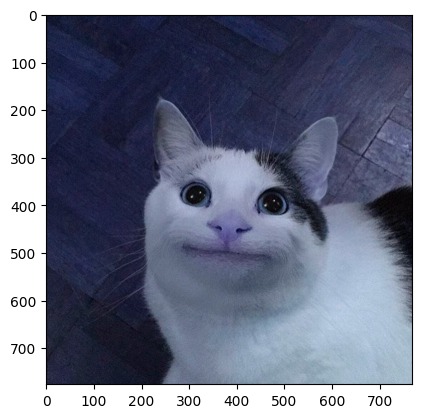

In [2]:
image = cv2.imread('./image.png')
plt.imshow(image);

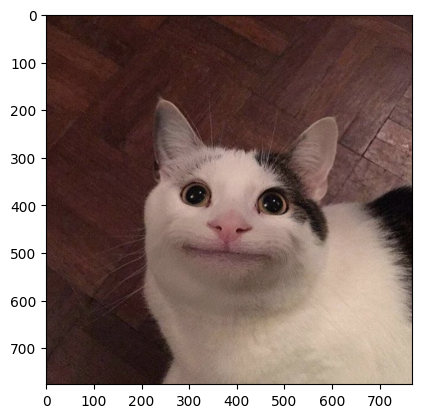

In [3]:
image_ex = image[...,::-1]
plt.imshow(image_ex)

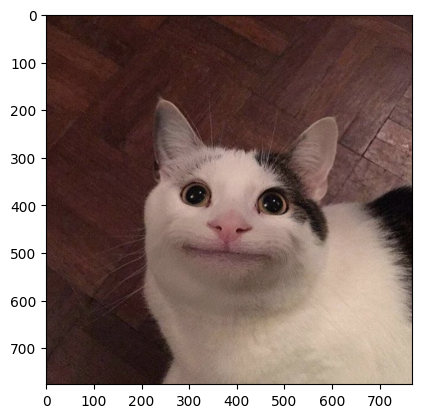

In [4]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb);

Посмотрим на каналы изображения отдельно

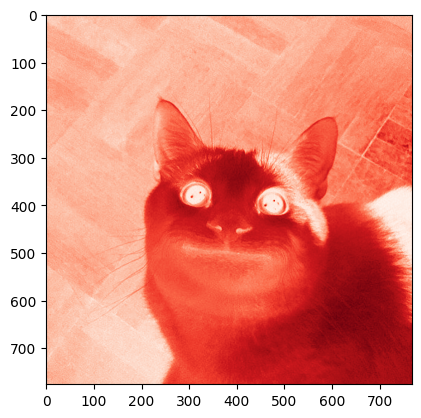

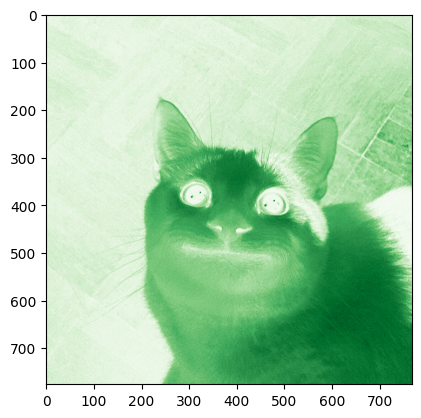

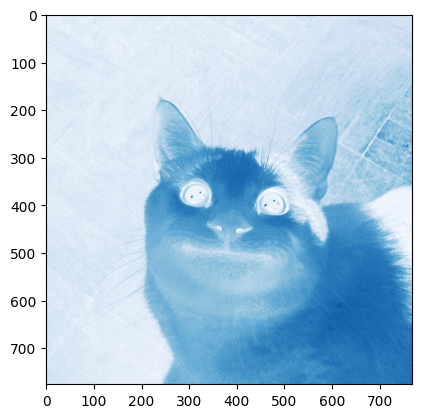

In [5]:
img_mat = np.array(image_rgb)
plt.imshow(img_mat[:, :, 0], cmap=cm.Reds)
plt.show()

img_mat = np.array(image_rgb)
plt.imshow(img_mat[:, :, 1], cmap=cm.Greens)
plt.show()

img_mat = np.array(image_rgb)
plt.imshow(img_mat[:, :, 2], cmap=cm.Blues)
plt.show()

# Операция свертки

- Количество входных каналов `in_channels`
- Количество выходных каналов `out_channels`
- Размер ядра `kernel_size`
- Шаг `stride`
- Паддинг `padding`
- Режим паддинга `padding_mode` (`'zeros'`, `'reflect'`, ...)


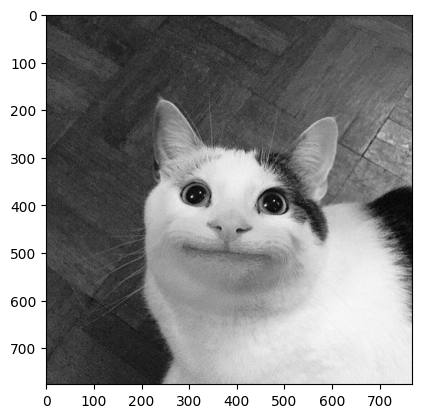

In [6]:
bw_image = cv2.imread('./image.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(bw_image, cmap=plt.cm.Greys_r)

In [7]:
# !pip3 install scipy

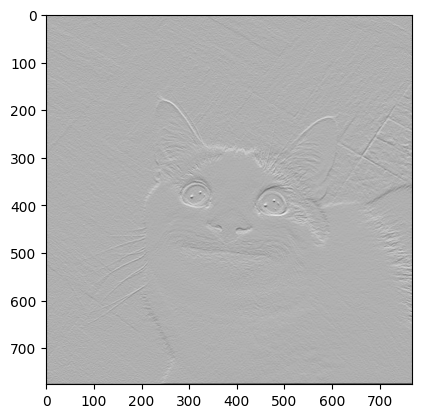

In [8]:
from scipy.signal import convolve2d

G_y = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])

res_y = convolve2d(bw_image, G_y, "same")
plt.imshow(res_y, cmap=plt.cm.Greys_r)

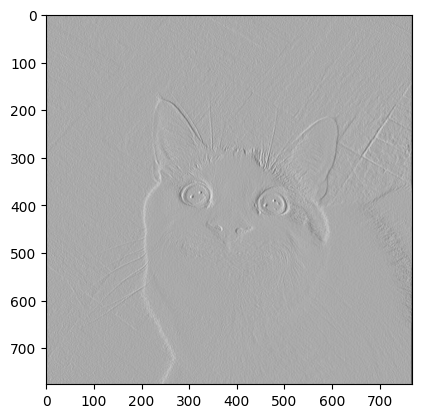

In [9]:
G_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

res_x = convolve2d(bw_image, G_y.T, "same")
plt.imshow(res_x, cmap=plt.cm.Greys_r)

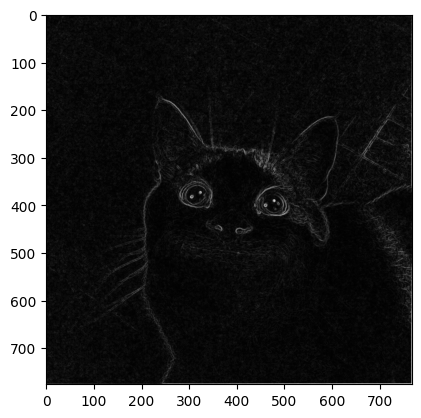

In [10]:
res_sobel = (res_x**2 + res_y**2)**0.5
plt.imshow(res_sobel, cmap=plt.cm.Greys_r)

# Пулинг

In [11]:
import numpy as np

conv_output = np.array([
    [10, 12,  8,  7],
    [ 4, 11,  5,  9],
    [18, 13,  7,  7],
    [ 3, 15,  2,  2]
])
conv_output

array([[10, 12,  8,  7],
       [ 4, 11,  5,  9],
       [18, 13,  7,  7],
       [ 3, 15,  2,  2]])

Сначала попробуем со `stride=2`

In [12]:
pool_size = 2
stride = 2

def get_pools(img=conv_output, pool_size=2, stride=2):

    pools = []
    for i in np.arange(conv_output.shape[0], step=stride):
        for j in np.arange(conv_output.shape[0], step=stride):
            mat = conv_output[i:i+pool_size, j:j+pool_size]
            pools.append(mat)
    pools = np.array(pools)
    return pools

pools = get_pools()
pools

array([[[10, 12],
        [ 4, 11]],

       [[ 8,  7],
        [ 5,  9]],

       [[18, 13],
        [ 3, 15]],

       [[ 7,  7],
        [ 2,  2]]])

In [13]:
def max_pooling(pools: np.array) -> np.array:

    num_pools = pools.shape[0]

    # Размер матрицы после пулинга
    tgt_shape = (int(np.sqrt(num_pools)), int(np.sqrt(num_pools)))

    # Здесь будем хранить максимумы с каждого из пулов
    pooled = []
    for pool in pools:
        pooled.append(np.max(pool))

    return np.array(pooled).reshape(tgt_shape)

In [14]:
max_pooling(pools=pools)

array([[12,  9],
       [18,  7]])

# Сверточная нейронная сеть

In [15]:
import torch
import torch.nn.functional as F
import torchvision
import os
from torch import nn
from tqdm import tqdm

In [16]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))
    ]
)

In [17]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [18]:
seed_everything(42)

mnist_train = torchvision.datasets.MNIST(
    './mnist/',
    train=True,
    download=True,
    transform=transform
)

mnist_val = torchvision.datasets.MNIST(
    './mnist/',
    train=False,
    download=True,
    transform=transform
)

train_dataloader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(mnist_val, batch_size=64, shuffle=True)

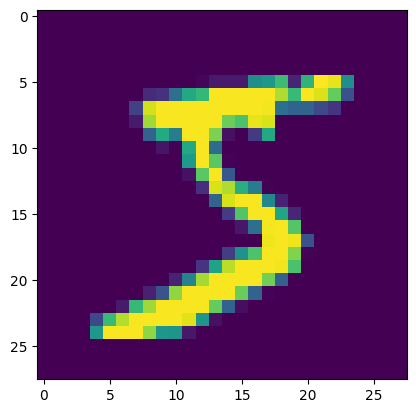

In [19]:
plt.imshow(mnist_train[0][0].squeeze(0).numpy().reshape([28, 28]))

In [20]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [21]:
def train(model, optimizer, n_epochs=5):
    for epoch in range(n_epochs):

        # обучение
        for x_train, y_train in tqdm(train_dataloader):
            y_pred = model(x_train)
            loss = F.cross_entropy(y_pred, y_train)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # валидация
        if epoch % 2 == 0:
            val_loss = []
            val_accuracy = []
            with torch.no_grad():
                for x_val, y_val in tqdm(val_dataloader):
                    y_pred = model(x_val)
                    loss = F.cross_entropy(y_pred, y_val)
                    val_loss.append(loss.numpy())
                    val_accuracy.extend((torch.argmax(y_pred, dim=-1) == y_val).numpy().tolist())

            print(f'Epoch: {epoch}, loss: {np.mean(val_loss)}, accuracy: {np.mean(val_accuracy)}')

In [22]:
train(model, optimizer)

100%|████████████████████████████████████████████████████████████████████████████████| 157/157 [00:01<00:00, 84.46it/s]


Epoch: 0, loss: 0.3202982246875763, accuracy: 0.9098


100%|████████████████████████████████████████████████████████████████████████████████| 157/157 [00:01<00:00, 83.34it/s]


Epoch: 2, loss: 0.23290136456489563, accuracy: 0.9315


100%|████████████████████████████████████████████████████████████████████████████████| 157/157 [00:01<00:00, 82.61it/s]

Epoch: 4, loss: 0.1869591921567917, accuracy: 0.9461


In [23]:
0.9462

0.9462

In [24]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5),  # grayscale
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=4),   # сократим изображение в 4 раза по каждой из сторон
    nn.Flatten(),
    nn.Linear(6*6*10, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [25]:
train(model, optimizer)

100%|████████████████████████████████████████████████████████████████████████████████| 157/157 [00:02<00:00, 77.04it/s]


Epoch: 0, loss: 0.26598459482192993, accuracy: 0.925


100%|████████████████████████████████████████████████████████████████████████████████| 157/157 [00:02<00:00, 77.54it/s]


Epoch: 2, loss: 0.12696349620819092, accuracy: 0.9628


100%|████████████████████████████████████████████████████████████████████████████████| 157/157 [00:02<00:00, 74.14it/s]

Epoch: 4, loss: 0.08601347357034683, accuracy: 0.9747


In [26]:
0.9747

0.9747

# Домашнее задание

Обучите сверточную нейронную сеть на датасете MNIST, взяв любой другой оптимизатор (кроме SGD) и любую другую функцию ошибки (кроме cross-entropy loss). Попробуйте поварьировать параметры: кол-во ядер, `kernel_size` и побить текущий бейзлайн в `0.9747`. Выведите количество обучаемых параметров.    
Какого качества удалось достичь? Попробуйте залоггировать Ваши результаты - построить графики того, как менялись метрики качества (accuracy, loss) с течением эпох, включить логгирование, сравнить результаты между собой при разных параметрах.

Любые дополнительные улучшения (как по методам, так и по коду пайплайна) приветствуются!

*Цель:* выработать навык обучения нейронных сетей (в частности сверточных) на основе средств PyTorch, начиная от загрузки датасетами и заканчивая выводами результатов, их логгированием, сравнением и анализом.

In [35]:
def my_train(model, optimizer, criterion, train_dataloader, val_dataloader, n_epochs = 4):
    for epoch in range(n_epochs):
        
        # обучение
        model.train()
        train_loss = 0.0
        loop = tqdm(train_dataloader, leave=False)
        
        for x_train, y_train in loop:
            optimizer.zero_grad()
            y_pred = model(x_train)
            loss = criterion(y_pred, y_train)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_dataloader)
        train_losses.append(train_loss)

        # валидация
        model.eval() 
        correct = 0
        total = 0
        with torch.no_grad():
            for x_val, y_val in val_dataloader:
                outputs = model(x_val)
                _, predicted = torch.max(outputs.data, 1)
                total += y_val.size(0)
                correct += (predicted == y_val).sum().item()

        accuracy = correct / total
        test_accuracies.append(accuracy)
        print(f'Epoch: {epoch}, loss: {train_loss}, accuracy: {accuracy:.4f}')

In [32]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=4),

    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=4),

    nn.Flatten(),

    nn.Linear(64, 256), 
    nn.ReLU(),

    nn.Linear(256, 10)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [33]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 38026


In [34]:
train_losses = []
test_accuracies = []
my_train(model, optimizer, criterion, train_dataloader, val_dataloader)

Epoch: 0, loss: 0.3805334135802633, accuracy: 0.9280


Epoch: 1, loss: 0.22350234693206195, accuracy: 0.9129


Epoch: 2, loss: 0.20160169440951112, accuracy: 0.9307


Epoch: 3, loss: 0.19490474387050183, accuracy: 0.9411


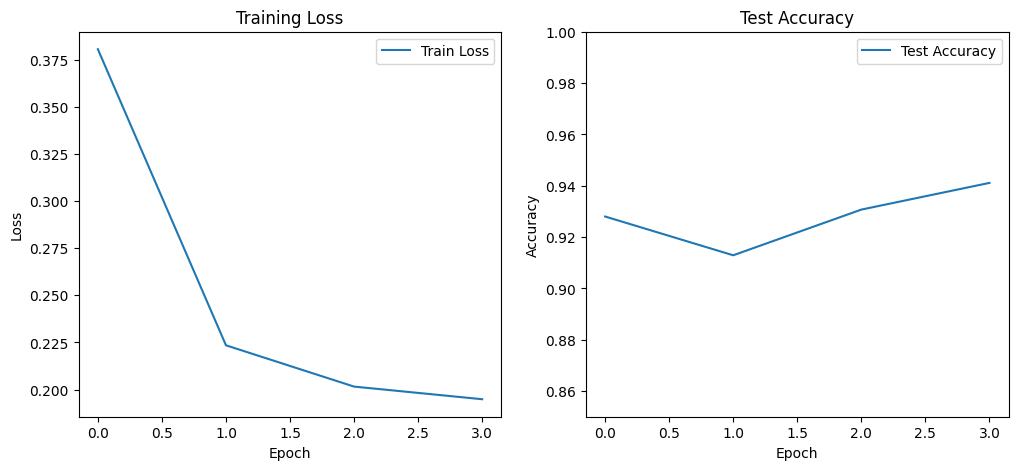

Best accuracy: 0.9411


In [36]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.legend()
plt.ylim(0.85, 1.00)
plt.show()

print(f"Best accuracy: {max(test_accuracies):}")

In [37]:
train_losses = []
test_accuracies = []
my_train(model, optimizer, criterion, train_dataloader, val_dataloader,  n_epochs = 10)

Epoch: 0, loss: 0.1821055234834822, accuracy: 0.9515


Epoch: 1, loss: 0.17332699918932815, accuracy: 0.9511


Epoch: 2, loss: 0.17381994549764881, accuracy: 0.9478


Epoch: 3, loss: 0.16424923186659066, accuracy: 0.9438


Epoch: 4, loss: 0.1633360096201825, accuracy: 0.9525


Epoch: 5, loss: 0.16027637127079944, accuracy: 0.9541


Epoch: 6, loss: 0.15885630263678874, accuracy: 0.9570


Epoch: 7, loss: 0.15629963084622456, accuracy: 0.9599


Epoch: 8, loss: 0.1539386473179086, accuracy: 0.9540


Epoch: 9, loss: 0.15076178115909733, accuracy: 0.9499


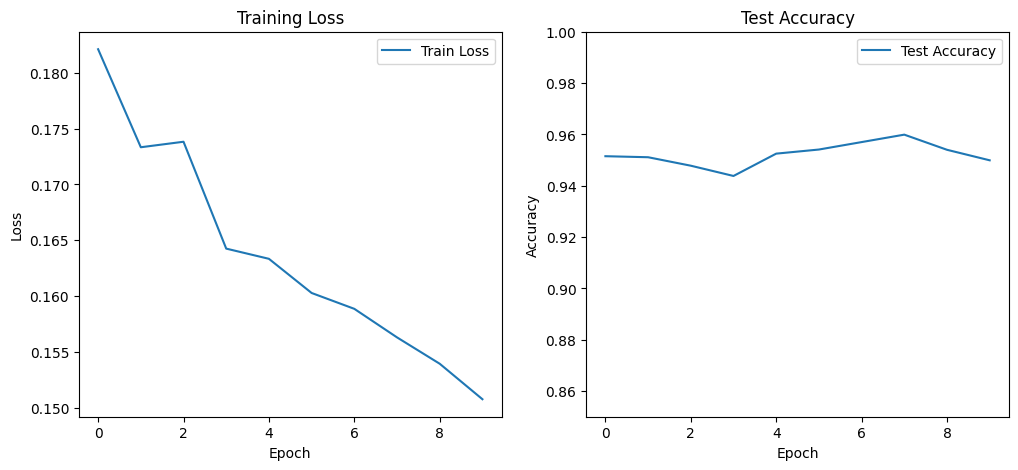

Best accuracy: 0.9599


In [38]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.legend()
plt.ylim(0.85, 1.00)
plt.show()

print(f"Best accuracy: {max(test_accuracies):}")

In [39]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # Меньший pooling сохраняет больше информации

    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),

    nn.Linear(64 * 7 * 7, 256), 
    nn.ReLU(),

    nn.Linear(256, 10)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [40]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 824458


In [41]:
train_losses = []
test_accuracies = []
my_train(model, optimizer, criterion, train_dataloader, val_dataloader)

Epoch: 0, loss: 0.30635148136695817, accuracy: 0.9407


Epoch: 1, loss: 0.17879598572262442, accuracy: 0.9324


Epoch: 2, loss: 0.1577235421280998, accuracy: 0.9559


Epoch: 3, loss: 0.14375139097931353, accuracy: 0.9609


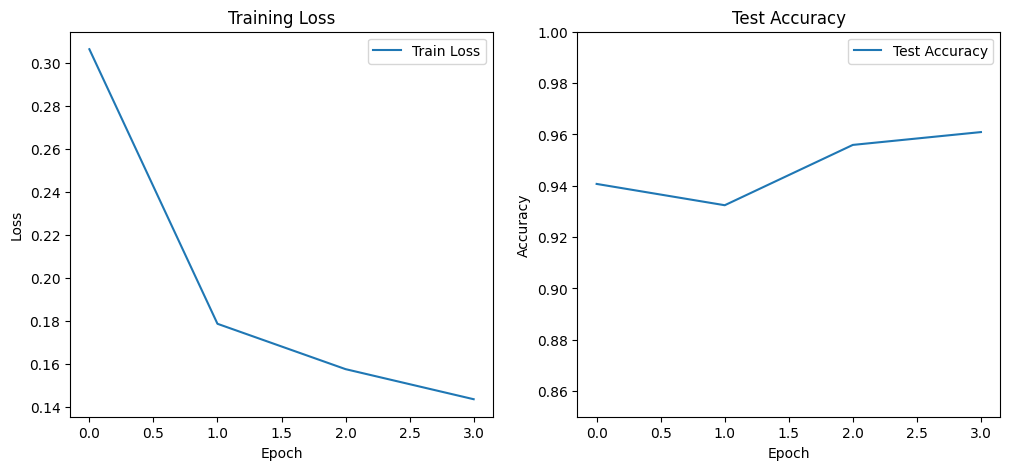

Best accuracy: 0.9609


In [42]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.legend()
plt.ylim(0.85, 1.00)
plt.show()

print(f"Best accuracy: {max(test_accuracies):}")

In [43]:
train_losses = []
test_accuracies = []
my_train(model, optimizer, criterion, train_dataloader, val_dataloader, n_epochs = 10)

Epoch: 0, loss: 0.13842033928355524, accuracy: 0.9580


Epoch: 1, loss: 0.1314685243978175, accuracy: 0.9542


Epoch: 2, loss: 0.13110471967218526, accuracy: 0.9644


Epoch: 3, loss: 0.12200073406362394, accuracy: 0.9598


Epoch: 4, loss: 0.1250794767933304, accuracy: 0.9606


Epoch: 5, loss: 0.11468024911911988, accuracy: 0.9544


Epoch: 6, loss: 0.11441622730116172, accuracy: 0.9613


Epoch: 7, loss: 0.11420516412891844, accuracy: 0.9631


Epoch: 8, loss: 0.10872600685262969, accuracy: 0.9635


Epoch: 9, loss: 0.10180653876581315, accuracy: 0.9599


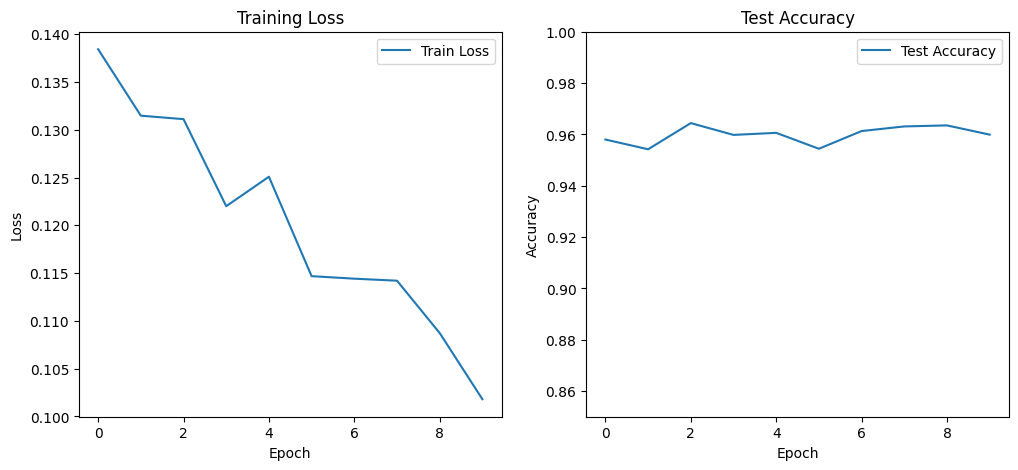

Best accuracy: 0.9644


In [44]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.legend()
plt.ylim(0.85, 1.00)
plt.show()

print(f"Best accuracy: {max(test_accuracies):}")